# 22회차 기출문제 해답


## 문제 1

미국 국립 당뇨병 연구소의 데이터 일부로 피마 인디언의 21세 이상여성이 대상입니다. 데이터를 수집한 목적은 특정 변수를 활용해서 피마 인디언의 당뇨병 유무를 예측하는 것입니다.

**Data description**

-   Pregnancies : 임신 횟수
-   Glucose : 혈장 포도당 농도
-   pressure : 혈압 (mm Hg)
-   triceps : 삼두 피부 두께 (mm)
-   insulin : 2시간 혈청 인슐린 (mu U/ml)
-   BMI : bmi 지수($\frac{체중(kg)}{(키(m)\cdot 0.01)^2}$)
-   DiabetesPedigreeFunction : 당뇨유전인자
-   Age : 나이(years)
-   Outcome : 당뇨 유무

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, plot_roc_curve, roc_auc_score, roc_curve, f1_score
from sklearn import set_config
set_config(display="diagram")
import warnings
warnings.filterwarnings('ignore')

In [2]:
dat = pd.read_csv('problem1.csv')
dat.columns = dat.columns.str.strip().str.lower().str.replace(' ', '_')

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**1. 탐색적 데이터 분석을 수행하시오(시각화 포함).**

In [4]:
y = dat['outcome']
X = dat.drop(['outcome'], axis = 1)

In [5]:
dat.isna().sum()

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64

데이터에 결측치는 존재하지 않는다.

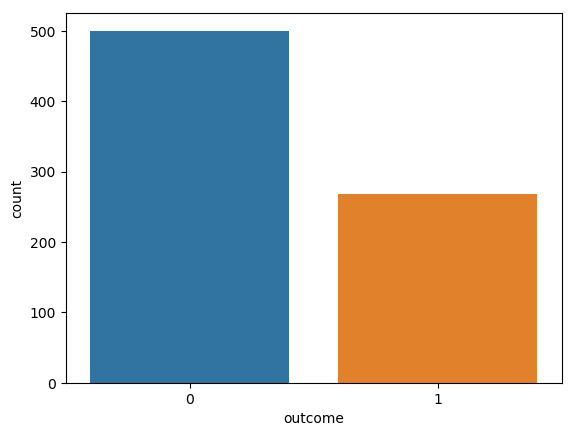

In [6]:
sns.countplot(y.astype(str));
plt.show();

outcome(당뇨 유무)의 경우 class 불균형이 존재한다.

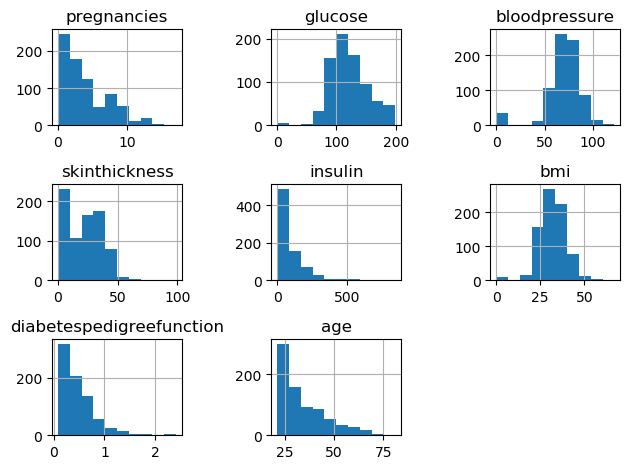

In [7]:
X.hist();
plt.tight_layout()
plt.show();

-   glucose(혈장 포도당 농도)가 0인 경우가 존재함

-   혈압이 0인 경우가 존재함

-   삼두 피부 두께가 0인 경우가 존재함

-   bmi가 0인 경우가 존재함

-   age(나이), diabetes_pedigree_funcion(당뇨유전인자), pregnancies(임신횟수), insulin 등의 경우 우측으로 긴꼬리를 갖는 분포임

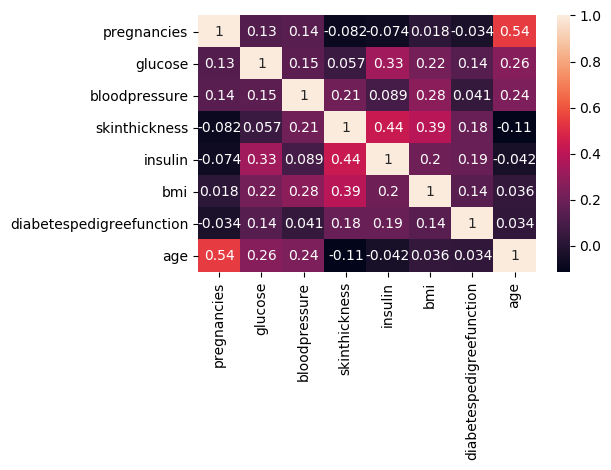

In [8]:
corr = X.select_dtypes('number').corr()
sns.heatmap(corr, annot = True);
plt.tight_layout();
plt.show();

-   age(나이)와 pregnancies(임신횟수) 사이에는 양의 상관관계(0.54)가 존재함

-   insulin(2시간 혈청 인슐린)과 skin_thickness(삼두 피부 두께) 사이에는 양의 상관관계(0.43)가 존재함

**2. 이상치를 처리하시오.**

In [9]:
dat2 = dat.loc[(dat.bloodpressure != 0) & (dat.skinthickness != 0) & (dat.bmi != 0)]

bmi, skin thickness(삼두 피부 두께), blood_pressure(혈압)이 0인 경우가 존재한다. 사람의 신체 구조상 0이 나올 수 없으므로 데이터 입력 오류로 판단하여 제거한다.

상자그림을 통해 이상치를 확인한다. 이상치 체크 전 훈련 데이터와 테스트 데이터를 분할한다.

In [10]:
y = dat2['outcome']
X = dat2.drop(['outcome'], axis = 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [11]:
Q1 = np.quantile(train_X.pregnancies, 0.25)
Q3 = np.quantile(train_X.pregnancies, 0.75)
IQR = Q3 - Q1
UC = Q3 + (1.5 * IQR) 
LC = Q3 - (1.5 * IQR) 

train_X.loc[(train_X.pregnancies > UC) | (train_X.pregnancies < LC), :]
outlier = train_X.loc[(train_X.pregnancies > UC) | (train_X.pregnancies < LC), :].index.tolist()

In [12]:
train_X_eda = train_X.copy()
train_X_eda = train_X_eda.assign(outlier = np.where(train_X_eda.index.isin(outlier), 1, 0))

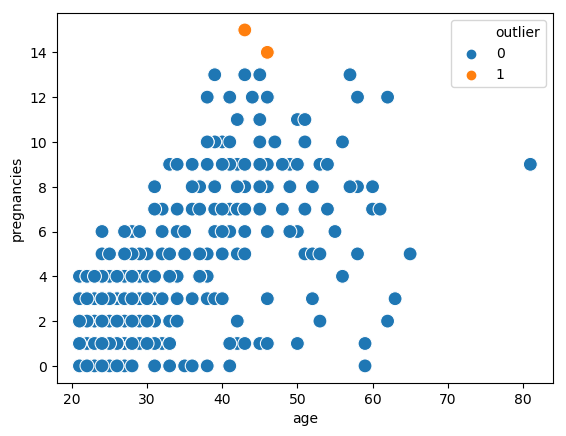

In [13]:
sns.scatterplot(x='age', 
                y='pregnancies',
                hue='outlier',
                s=100, # marker size
                data=train_X_eda);
plt.show();

상자그림을 통해 이상치를 선별하면 나이가 40\~60대에 임신 횟수가 12번 이상인 경우이다. 인디언이라는 특성을 고려했을 때, 임신이 가능한 나이를 15살로 고려해보면 산술적으로 가능한 경우에 해당하므로 이상치로 제거하지 않는다.

**3. 앞선 두 단계에서 얻은 향후 분석시 고려사항에 대해 작성하시오.**

반응변수(당뇨 유무)를 보면 yes의 빈도가 no의 빈도보다 많은 편향된 분포 형태이다. 반응변수의 클래스가 불균형할 경우 다수 범주에 과적합이 될 수 있다. 따라서 오버샘플링, 언더샘플링 기법을 고려해볼 수 있다.

**4. 오버샘플링 과정에 대해 설명하고 결과를 작성하시오.**

오버샘플링은 클래스가 불균형일 때 빈도가 낮은 levels에 해당하는 표본을 복원 추출을 통해 빈도가 높은 levels에 해당하는 표본의 수만큼 관측치를 복제함으로써 클래스 균형을 맞추는 방법이다.

In [14]:
oversample = RandomOverSampler(sampling_strategy='minority')
train_X_over, train_y_over = oversample.fit_resample(train_X, train_y)
print(Counter(train_y_over))

Counter({1: 287, 0: 287})


**4. 언더샘플링 과정에 대해 설명하고 결과를 작성하시오.**

언더샘플링은 클래스가 불균형일 때 빈도가 높은 levels에 해당하는 표본을 빈도가 적은 levels에 해당하는 표본의 수만큼 무작위 추출해서 클래스 균형을 맞추는 방법이다.

In [15]:
undersample = RandomUnderSampler(sampling_strategy='majority')
train_X_under, train_y_under = undersample.fit_resample(train_X, train_y)
print(Counter(train_y_under))

Counter({0: 142, 1: 142})


**5. 둘 중 한가지를 선택하고 이유를 작성하시오.**

이상치 제거 과정에서 데이터의 소실이 발생했기 때문에 언더샘플링을 할 경우 더욱더 많은 데이터가 제거되므로 너무 많은 정보의 손실이 발생하므로, 오버샘플링을 진행한다.

**6. 최소 3개 이상 모델을 제시하고, 정확도 측면의 모델 1개와 속도 측면의 모델 1개를 구현하시오.**

-   Decision tree

Decision tree는 나무구조를 활용한 의사결정 규칙을 통해서 분류 혹은 예측을 수행하는 방법이다. 범주형 변수의 경우 gini index, cross entropy, 연속형 변수의 경우 SSE를 활용하여, 데이터에 맞는 적절한 분할 기준을 구축하여 의사결정나무를 생성한다. 단일의사결정나무의 경우 시각화를 통해 해석의 장점이 있다.

-   Random forest Random forest는 Bagging을 의사결정나무에 적용하여 의사결정나무의 단점인 예측력의 분산이 큰 단점을 보완한 모형이다. Decision tree과 성능 비교를 위해 활용한다.

-   XGBOOST

Gradient Boosting 알고리즘을 기반으로 한 모델로 여러 개의 약한 예측 모델(주로 결정 트리)을 순차적으로 결합하여 강력한 예측 모델을 만드는 앙상블 기법이다. XGBOOST는 Gradient Boosting 알고리즘에서 더 나아가 특히, 대규모 데이터셋에 대해 빠른 학습을 지원하고, 과적합을 방지하는 다양한 기법을 제공한다.

Decision Tree는 데이터 해석에 강점이 있고, Random Forest는 예측 성능이 뛰어나고 과적합 문제를 해결할 수 있는 안정적인 앙상블 기법이므로 두 알고리즘을 선택한다.

모델 튜닝은 파라미터의 범위를 제한하여 진행하였으며, 반복 5-fold 교차검증을 통해 validation 데이터를 여러번 생성 후 적합하여, 하이퍼파라미터별 모형 성능을 교차 검증하였다.

**Random forest**

In [16]:
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestClassifier
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

pipe_rf = Pipeline(
    [
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", RandomForestClassifier())
    ]
)

RandomForest_param = {'classifier__max_features': np.arange(0.5, 1, 0.1)}

start_time = time.time()
RandomForest_search = GridSearchCV(estimator = pipe_rf, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
RandomForest_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('RandomForest best score : ', RandomForest_search.best_score_)

3.785996913909912s
RandomForest best score :  0.7371366429269655


**Decision tree**

In [17]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline(
    [
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", DecisionTreeClassifier())
    ]
)

decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

start_time = time.time()
decisiontree_search = GridSearchCV(estimator = pipe_dt, 
                      param_grid = decisiontree_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
decisiontree_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('decision tree best score : ', decisiontree_search.best_score_)

0.3659958839416504s
decision tree best score :  0.667969696969697


**7. 모델별로 비교하고 결과를 설명하시오.**

반응변수의 각 범주간 빈도가 불균형할 때, 소수 범주에 비해서 다수 범주에 더 많은 가중치가 부여되어 소수 범주에 대한 분류를 어렵게 한다. 따라서 이러한 문제를 보완할 수 있는 평가지표를 고려해야 하므로, 위에 제시한 평가지표 중 Balanced accuracy를 고려해볼 수 있다. balanced accuracy 기준으로 Random forest가 가장 좋다.

최종 테스트 데이터에서의 모델 성능은 다음과 같다.

In [18]:
pred_rf = RandomForest_search.predict(test_X)
print(classification_report(test_y, pred_rf))
print(balanced_accuracy_score(test_y, pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        71
           1       0.74      0.62      0.68        37

    accuracy                           0.80       108
   macro avg       0.78      0.75      0.76       108
weighted avg       0.79      0.80      0.79       108

0.7544727826417967


**8. 속도 측면의 개선을 위해 차원 축소를 수행하고, 예측 성능 및 속도 면에서의 결과를 작성하시오.**

차원 축소 기법 중 주성분분석을 고려한다. 누적분산비율을 80% 선에서 주성분을 선택한다.

In [19]:
pca_pipe = Pipeline([("scaler", StandardScaler()), 
                     ("PCA", PCA(n_components= 0.8, svd_solver='full'))])

주성분분석을 활용하여 모델을 다시 적합한다.

In [20]:
preprocess = ColumnTransformer(
    [("num_process", pca_pipe, train_X.columns)], 
    remainder='passthrough'
)

pipe_rf2 = Pipeline(
    [
        ("preprocess", preprocess),
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", RandomForestClassifier())
    ]
)

RandomForest_param = {'classifier__max_features': np.arange(0.5, 1, 0.1)}

start_time = time.time()
RandomForest_search2 = GridSearchCV(estimator = pipe_rf2, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
RandomForest_search2.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

3.6659975051879883s


In [21]:
pred_rf2 = RandomForest_search2.predict(test_X)
print(classification_report(test_y, pred_rf2))
print(balanced_accuracy_score(test_y, pred_rf2))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80        71
           1       0.61      0.59      0.60        37

    accuracy                           0.73       108
   macro avg       0.70      0.70      0.70       108
weighted avg       0.73      0.73      0.73       108

0.6987057480015226


주성분분석을 수행했을 때, 모델 계산 속도가 증가하였으며, 모델 성능 또한 감소하였다.

## 문제 2

한 중소기업이 새로운 IoT 장비를 개발하여 생산에 도입했습니다. 이 장비는 각기 다른 200개의 장치가 다양한 환경에서 작동하며, 각 장치의 성능과 오류 발생률을 모니터링하는 것이 기업의 주요 과제가 되었습니다. 이를 통해 장치의 신뢰성을 평가하고, 문제가 발생할 경우 신속히 대응하기 위해 p 관리도를 사용하기로 했습니다.

이 기업은 각 장치가 100번의 작동을 수행한다고 가정하고, 각 장치의 작동 중 발생한 오류 수를 기록했습니다. 데이터는 장치 번호에 따라 정리되었으며, 이 정보는 공정이 안정적인지 여부를 파악하고, 특정 장치가 비정상적으로 많은 오류를 발생시키는지 확인하기 위해 사용됩니다.

**1. p(불량률) 관리도에 따라 관리중심선, 관리 상한선 및 하한선을 구하시오.**

In [22]:
dat = pd.read_csv('problem2.csv')

In [23]:
dat['n'] = 100

불량률을 계산하면 다음과 같다. 

In [24]:
dat['p'] = dat['error_case_number'] / dat['n']

관리중심선을 구하면 다음과 같다. 

In [25]:
center_line = dat['p'].mean()

관리 상한선 및 하한선은 다음과 같다.

In [26]:
UCL = center_line + 3 * np.sqrt(center_line * (1 - center_line) / dat['n'].mean())
LCL = center_line - 3 * np.sqrt(center_line * (1 - center_line) / dat['n'].mean())
LCL = max(0, LCL)  # 하한선이 음수가 되지 않도록 0으로 설정

**2. 관리도를 시각화하시오.**

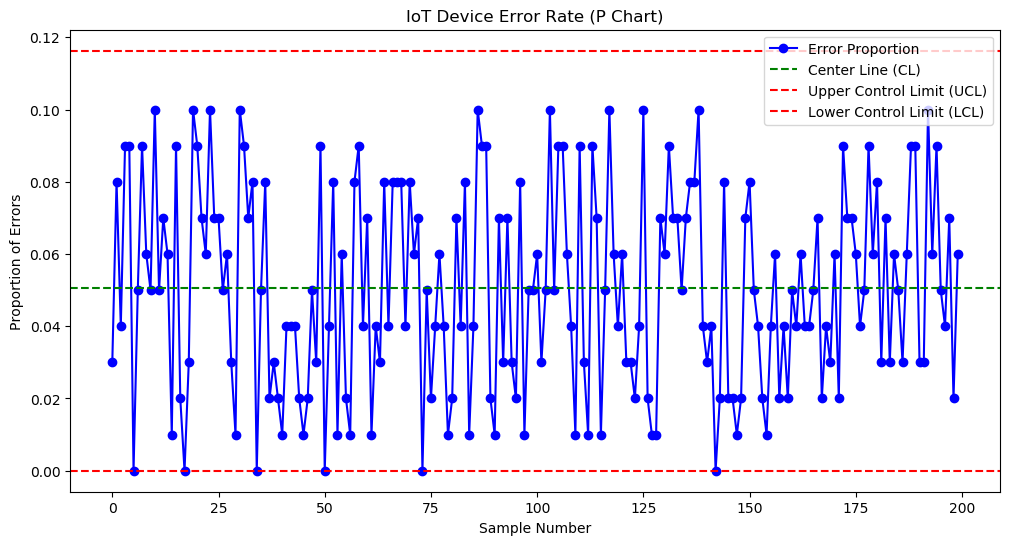

In [27]:
plt.figure(figsize=(12, 6));
plt.plot(dat.index, dat['p'], marker='o', linestyle='-', color='blue', label='Error Proportion');
plt.axhline(y=center_line, color='green', linestyle='--', label='Center Line (CL)');
plt.axhline(y=UCL, color='red', linestyle='--', label='Upper Control Limit (UCL)');
plt.axhline(y=LCL, color='red', linestyle='--', label='Lower Control Limit (LCL)');

plt.title('IoT Device Error Rate (P Chart)');
plt.xlabel('Sample Number');
plt.ylabel('Proportion of Errors');
plt.legend();
plt.show();

## 문제 3

한 식품 회사가 두 가지 제품, 제품 A와 제품 B를 생산하고 있습니다. 이 두 제품은 각각 P와 Q라는 두 가지 주요 원재료를 사용하며, 회사는 원재료와 생산 능력을 고려해 이익을 극대화하려고 합니다.

**제품 정보**

-   제품 A는 6단위의 P와 2단위의 Q가 필요합니다.
-   제품 B는 3단위의 P와 4단위의 Q가 필요합니다.

|     | P   | Q   |
|:----|:----|:----|
| A   | 6   | 2   |
| B   | 3   | 4   |

각 제품의 생산량을 조정하여, 제한된 자원 내에서 최대 이익을 계산하시오.

**제약 조건**

-   원재료 P는 최대 420단위까지만 사용할 수 있습니다.
-   원재료 Q는 최대 280단위까지만 사용할 수 있습니다.

제약 조건 식을 정리하면 다음과 같다.

$6x + 3y \le 420$(원재료 P에 대한 제약 조건)

$2x + 4y \le 280$(원재로 Q에 대한 제약 조건)

$900x + 600y = z$

::: callout-note
PuLP=2.5.0은 ADP 패키지 지원 리스트에 있으므로, 해당 패키지를 이용하면 됩니다. ortools 패키지는 ADP 패키지 지원 리스트에 없으므로 사전에 패키지를 설치해야 합니다.
:::

In [28]:
import pulp
prob = pulp.LpProblem("Maximize Profit", pulp.LpMaximize)
x1 = pulp.LpVariable('x1', lowBound=0, cat='Integer')
x2 = pulp.LpVariable('x2', lowBound=0, cat='Integer')

In [29]:
prob += 900 * x1 + 600 * x2
prob += 6 * x1 + 3 * x2 <= 420
prob += 2 * x1 + 4 * x2 <= 280

prob.solve()

optimum_solution = [pulp.value(x1), pulp.value(x2)]
optimum_value = pulp.value(prob.objective)

print(f"최적해: {optimum_solution}")
print(f"최대 이익: {optimum_value}")

최적해: [47.0, 46.0]
최대 이익: 69900.0


최대 이익은 69900이다.

## 문제 4

금속 성분 함유량 데이터 ‑ 제품에 금속 재질 함유량의 분산이 1.3을 넘으면 불량이라고 보고 있는데, 제조사별로 차이가 난다고 제보를 받았다. 주어진 회사 제품의 분산에 대해 검정을 수행하시오. (유의수준 5%)

In [30]:
dat = pd.read_csv('problem4.csv')

**1. 귀무가설과 대립가설을 설정하시오.**

-   귀무가설 : 제품의 금속 재질 함유량의 분산이 1.3 이하이다.

-   대립가설 : 제품의 금속 재질 함유량의 분산이 1.3을 초과한다.

**2. 가설 검정 결과를 해석하시오.**

In [31]:
from scipy.stats import chi2
n = len(dat['x'])
sample_variance = dat['x'].var()
sigma_squared = 1.3

# 검정 통계량 계산
chi_squared_stat = (n - 1) * sample_variance / sigma_squared
p_value = 1 - chi2.cdf(chi_squared_stat, df=n - 1)

print(f"검정 통계량: {chi_squared_stat}")
print(f"p-value: {p_value}")

검정 통계량: 42.86419577184893
p-value: 0.046860593894074154


유의수준 5%에서 p-value = 0.04로 작으므로, 귀무가설을 기각한다. 따라서 제품의 금속 재질 함유량의 분산이 1.3을 초과한다.

## 문제 5

구매하는 패턴으로 봐서 두 상품이 연관이 있는지 가설을 세우고 검정하시오.

$$A, A, A, B, B, A, A, A, A, B, A, B, B, B, A, A, A, A, B, B, A, A, A, B, B$$

In [32]:
run_sample = ["A", "A", "A", "B", "B", "A", "A", "A", "A", 
              "B", "A", "B", "B", "B", "A", "A", "A", "A", 
              "B", "B", "A", "A", "A", "B", "B"]

-   귀무가설 : 관측치는 randomness를 만족한다.

-   대립가설 : 관측치는 randomness를 만족하지 않는다.


A, B를 0, 1로 변환합니다. 

In [33]:
from statsmodels.sandbox.stats.runs import runstest_1samp
run_sample_binary = [1 if x == "A" else 0 for x in run_sample]

In [34]:
z_stat, p_value = runstest_1samp(run_sample_binary, correction=False)

print(f"검정 통계량: {z_stat}")
print(f"p-value: {p_value}")

검정 통계량: -1.2792042981336627
p-value: 0.2008251226951454


유의수준 5% 하에서 검정통계량 값 ‑1.2792에 대응하는 p‑value는 0.2008로 크기 때문에 귀무가설을 기각할 수 없다. 관측치는 무작위하게 발생된 표본으로 볼 수 있으며, 따라서 두 제품 구매 패턴에 연관성이 없다고 볼 수 있다.